Antes de correr el código, no olvidar cargar el DATASET

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics

In [ ]:
df = pd.read_excel('/content/sample_data/Data_Train.xlsx')

In [ ]:
df.head().max()

Airline                      Jet Airways
Date_of_Journey                9/06/2019
Source                           Kolkata
Destination                    New Delhi
Route              DEL → LKO → BOM → COK
Dep_Time                           22:20
Arrival_Time                       23:30
Duration                          7h 25m
Total_Stops                     non-stop
Additional_Info                  No info
Price                              13882
dtype: object

In [ ]:
erase=df.drop(["Date_of_Journey", "Route", "Dep_Time", "Arrival_Time", "Duration", "Total_Stops", "Additional_Info", "Price"], axis =1)

In [ ]:
num_var=df.Price

In [ ]:
erase.describe()

,Airline,Source,Destination
count,10683,10683,10683
unique,12,5,6
top,Jet Airways,Delhi,Cochin
freq,3849,4537,4537


In [ ]:
erase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Airline      10683 non-null  object
 1   Source       10683 non-null  object
 2   Destination  10683 non-null  object
dtypes: object(3)
memory usage: 250.5+ KB


In [ ]:
num_var.describe()

count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

**CONVERSIÓN DE VARIABLES A NUMÉRICA**

In [ ]:
dummiesair=pd.get_dummies(erase['Airline'])

In [ ]:
dummiessource=pd.get_dummies(erase['Source'])

In [ ]:
dummiesdest=pd.get_dummies(erase['Destination'])

In [ ]:
var_cat_num=pd.concat([erase, dummiesair,dummiessource,dummiesdest], axis=1)

In [ ]:
var_cat_num.head()

,Airline,Source,Destination,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,...,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,IndiGo,Banglore,New Delhi,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,0,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,0,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,0,0,0,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
oficial=var_cat_num.drop(['Airline','Source', 'Destination'], axis=1)

In [ ]:
oficial.head()

,Air Asia,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,...,Chennai,Delhi,Kolkata,Mumbai,Banglore,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**EMPEZAMOS CON LA GESTIÓN DEL MODELO**

REGRESIÓN MÚLTIPLE

    Iteración           MAE           MSE          RMSE           R^2  \
0           1  2.332343e+03  1.133546e+07  3.366817e+03  4.646461e-01   
1           2  2.234783e+03  1.022864e+07  3.198225e+03  5.347894e-01   
2           3  1.683745e+13  6.058390e+29  7.783566e+14 -3.027146e+22   
3           4  2.260428e+03  9.899994e+06  3.146426e+03  5.248911e-01   
4           5  1.521144e+13  4.944759e+29  7.031898e+14 -2.613047e+22   
..        ...           ...           ...           ...           ...   
95         96  2.325390e+03  9.876286e+06  3.142656e+03  5.180954e-01   
96         97  2.314497e+03  1.062234e+07  3.259193e+03  5.421929e-01   
97         98  2.234869e+03  9.888178e+06  3.144547e+03  5.311852e-01   
98         99  2.168196e+03  8.836185e+06  2.972572e+03  5.129877e-01   
99        100  2.207126e+03  9.330520e+06  3.054590e+03  5.282361e-01   

                                         Coeficientes  Intersección  \
0   [2.0499611814928856e+16, 2.0499611814932176e+1..

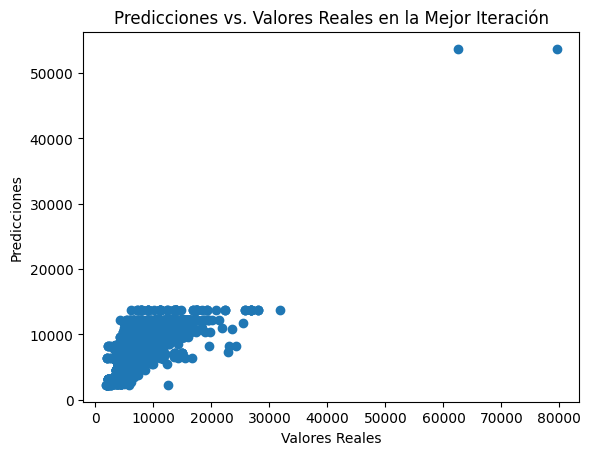

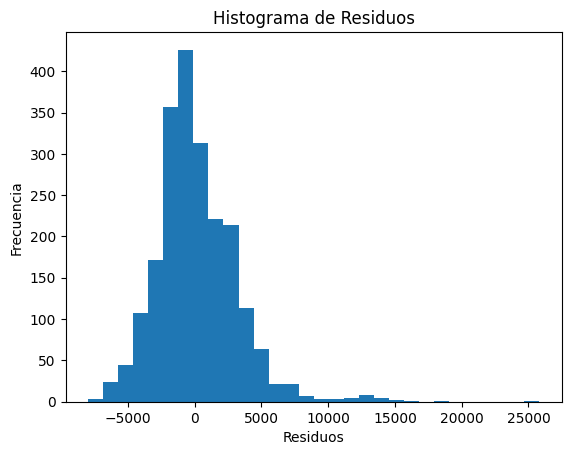

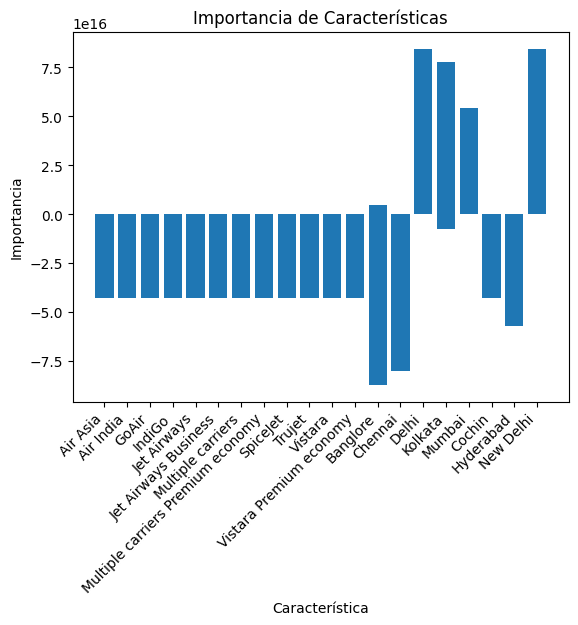

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

y = num_var
X = oficial

# Obtener nombres de características
nombres_caracteristicas = X.columns.tolist()

# Iterar para ajustar el modelo y hacer predicciones varias veces
num_iteraciones = 100
resultados = []

max_r2_iteration = None
max_r2_value = float('-inf')

for i in range(num_iteraciones):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    # Crear y entrenar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Hacer predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evaluar el rendimiento del modelo
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = metrics.mean_squared_error(y_test, y_pred, squared=False)
    r2 = metrics.r2_score(y_test, y_pred)

    # Almacenar los resultados en una lista
    resultados.append({
        'Iteración': i + 1,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'Coeficientes': model.coef_,
        'Intersección': model.intercept_,
        'Predicciones': y_pred,
        'Valores Reales': y_test.tolist()
    })

    # Actualizar el valor máximo de R^2 y la iteración correspondiente
    if r2 > max_r2_value:
        max_r2_value = r2
        max_r2_iteration = i + 1
        max_r2_predicciones = y_pred
        max_r2_valores_reales = y_test.tolist()

# Imprimir los resultados de todas las iteraciones
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

# Imprimir resultados de la iteración con el valor máximo de R^2
print("\nResultados de la iteración con el valor máximo de R^2:")
max_r2_row = resultados_df[resultados_df['Iteración'] == max_r2_iteration]
print(max_r2_row)

# Resumen de conclusiones
print("\nResumen de Conclusiones:")
print(f"Media MAE: {resultados_df['MAE'].mean()}")
print(f"Media MSE: {resultados_df['MSE'].mean()}")
print(f"Media RMSE: {resultados_df['RMSE'].mean()}")
print(f"Media R^2: {resultados_df['R^2'].mean()}")

# El valor más alto
print(f"\nValor MAE más alto: {resultados_df['MAE'].max()}")
print(f"Valor MSE más alto: {resultados_df['MSE'].max()}")
print(f"Valor RMSE más alto: {resultados_df['RMSE'].max()}")
print(f"Valor R^2 más alto: {max_r2_value}")

# Imprimir coeficientes de la iteración con el valor máximo de R^2 con nombres originales
print("\nCoeficientes de la iteración con el valor máximo de R^2:")
coeficientes_dict = dict(zip(nombres_caracteristicas, max_r2_row['Coeficientes'].values[0]))
print(f"Intersección: {max_r2_row['Intersección'].values[0]}")
for nombre, coef in coeficientes_dict.items():
    print(f"{nombre}: {coef}")

# Graficar las predicciones vs. valores reales en la iteración con el valor máximo de R^2
plt.scatter(max_r2_valores_reales, max_r2_predicciones)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales en la Mejor Iteración')
plt.show()

# Graficar el Histograma de Residuos
residuos = max_r2_valores_reales - max_r2_predicciones
plt.hist(residuos, bins=30)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()

# Graficar la Importancia de Características
importancias_caracteristicas = max_r2_row['Coeficientes'].values[0]
plt.bar(nombres_caracteristicas, importancias_caracteristicas)
plt.xlabel('Característica')
plt.ylabel('Importancia')
plt.title('Importancia de Características')
plt.xticks(rotation=45, ha='right')
plt.show()

# Graficar el Ajuste de Regresión (si tienes un solo predictor)
if len(nombres_caracteristicas) == 1:
    plt.scatter(X_test[nombres_caracteristicas[0]], y_test, label='Valores Reales')
    plt.plot(X_test[nombres_caracteristicas[0]], max_r2_predicciones, color='red', linewidth=2, label='Predicciones')
    plt.xlabel(nombres_caracteristicas[0])
    plt.ylabel('Variable Objetivo')
    plt.title('Ajuste de Regresión')
    plt.legend()
    plt.show()


**RANDOM FOREST**

    Iteración          MAE           MSE         RMSE       R^2  \
0           1  2137.673262  1.051487e+07  3242.663675  0.503401   
1           2  2040.522366  9.445068e+06  3073.282959  0.570427   
2           3  2125.786903  9.612167e+06  3100.349512  0.519717   
3           4  2076.912095  9.033530e+06  3005.583115  0.566473   
4           5  2062.910525  8.860775e+06  2976.705371  0.531754   
..        ...          ...           ...          ...       ...   
95         96  2149.839496  9.254132e+06  3042.060500  0.548453   
96         97  2121.177750  9.861559e+06  3140.311867  0.574982   
97         98  2069.392264  9.253339e+06  3041.930184  0.561284   
98         99  2001.357411  8.166413e+06  2857.693592  0.549903   
99        100  2007.165816  8.459579e+06  2908.535602  0.572272   

                       Importancia de características  \
0   [0.0006029443209745996, 0.11754350517609255, 0...   
1   [0.0010676357819736086, 0.1363487110204102, 0....   
2   [0.00090198887378065

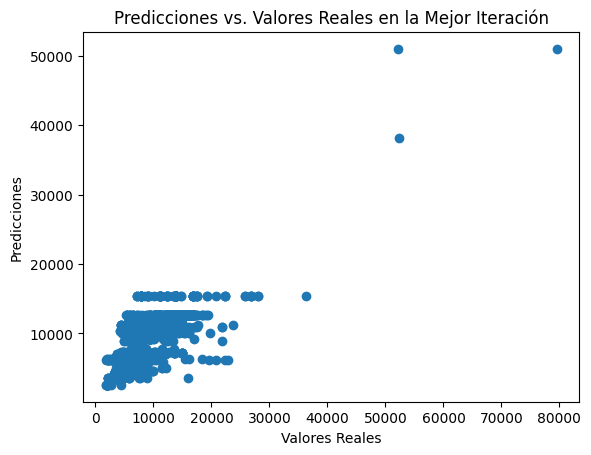

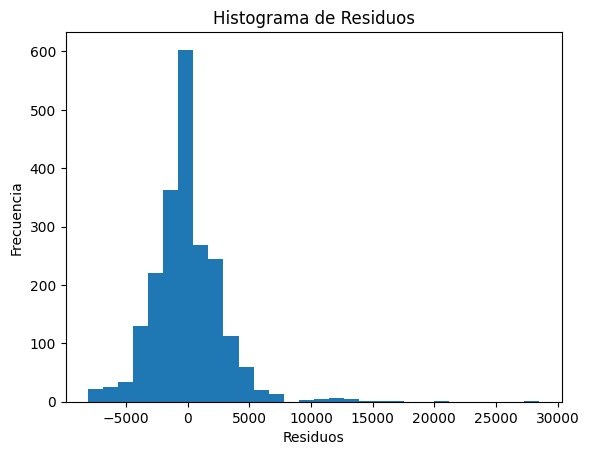

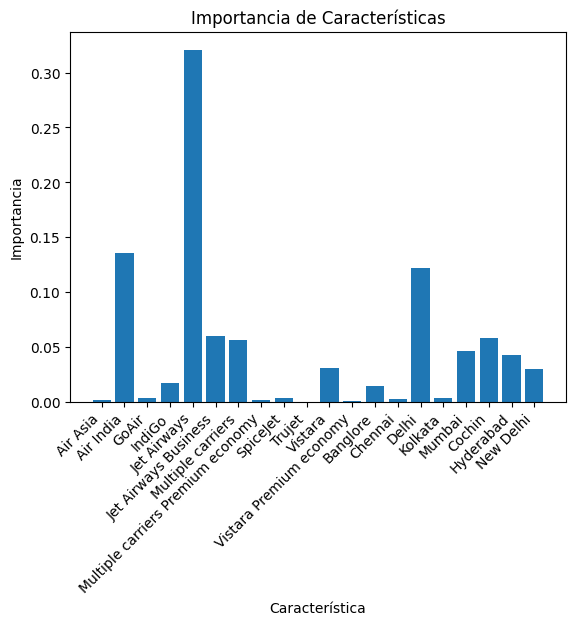

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics

y = num_var
X = oficial

# Obtener nombres de características
nombres_caracteristicas = X.columns.tolist()

# Iterar para ajustar el modelo y hacer predicciones varias veces
num_iteraciones = 100
resultados = []

max_r2_iteration = None
max_r2_value = float('-inf')
max_r2_predicciones = None
max_r2_valores_reales = None

for i in range(num_iteraciones):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    # Crear y entrenar el modelo Random Forest
    model = RandomForestRegressor(random_state=i)
    model.fit(X_train, y_train)

    # Hacer predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evaluar el rendimiento del modelo
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = metrics.mean_squared_error(y_test, y_pred, squared=False)
    r2 = metrics.r2_score(y_test, y_pred)

    # Almacenar los resultados en una lista
    resultados.append({
        'Iteración': i + 1,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'Importancia de características': model.feature_importances_,
        'Predicciones': y_pred,
        'Valores Reales': y_test.tolist()
    })

    # Actualizar el valor máximo de R^2 y la iteración correspondiente
    if r2 > max_r2_value:
        max_r2_value = r2
        max_r2_iteration = i + 1
        max_r2_predicciones = y_pred
        max_r2_valores_reales = y_test.tolist()

# Imprimir los resultados de todas las iteraciones
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

# Imprimir resultados de la iteración con el valor máximo de R^2
print("\nResultados de la iteración con el valor máximo de R^2:")
max_r2_row = resultados_df[resultados_df['Iteración'] == max_r2_iteration]
print(max_r2_row)

# Resumen de conclusiones
print("\nResumen de Conclusiones:")
print(f"Media MAE: {resultados_df['MAE'].mean()}")
print(f"Media MSE: {resultados_df['MSE'].mean()}")
print(f"Media RMSE: {resultados_df['RMSE'].mean()}")
print(f"Media R^2: {resultados_df['R^2'].mean()}")

# El valor más alto
print(f"\nValor MAE más alto: {resultados_df['MAE'].max()}")
print(f"Valor MSE más alto: {resultados_df['MSE'].max()}")
print(f"Valor RMSE más alto: {resultados_df['RMSE'].max()}")
print(f"Valor R^2 más alto: {max_r2_value}")

# Imprimir importancia de características de la iteración con el valor máximo de R^2
print("\nImportancia de características de la iteración con el valor máximo de R^2:")
importancias = max_r2_row['Importancia de características'].values[0]
for nombre, importancia in zip(nombres_caracteristicas, importancias):
    print(f"{nombre}: {importancia}")

# Graficar las predicciones vs. valores reales en la iteración con el valor máximo de R^2
plt.scatter(max_r2_valores_reales, max_r2_predicciones)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales en la Mejor Iteración')
plt.show()

# Graficar el Histograma de Residuos
residuos = max_r2_valores_reales - max_r2_predicciones
plt.hist(residuos, bins=30)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()

# Graficar la Importancia de Características
plt.bar(nombres_caracteristicas, importancias)
plt.xlabel('Característica')
plt.ylabel('Importancia')
plt.title('Importancia de Características')
plt.xticks(rotation=45, ha='right')
plt.show()

XBOOST

    Iteración          MAE           MSE         RMSE       R^2  \
0           1  2135.553487  1.051522e+07  3242.718734  0.503384   
1           2  2039.982213  9.447151e+06  3073.621725  0.570333   
2           3  2124.672311  9.604768e+06  3099.155943  0.520086   
3           4  2084.812804  9.135883e+06  3022.562292  0.561561   
4           5  2063.820752  8.865454e+06  2977.491163  0.531507   
..        ...          ...           ...          ...       ...   
95         96  2146.753639  9.202066e+06  3033.490681  0.550993   
96         97  2121.550412  9.738818e+06  3120.707986  0.580271   
97         98  2071.901836  9.311550e+06  3051.483290  0.558524   
98         99  2001.550927  8.167970e+06  2857.966066  0.549817   
99        100  2007.802096  8.463057e+06  2909.133414  0.572096   

                          Características Importantes  \
0   [0.00042542408, 0.067759655, 0.00044045778, 0....   
1   [0.0010442376, 0.071875, 0.0007919062, 0.00640...   
2   [0.00034929198, 0.07

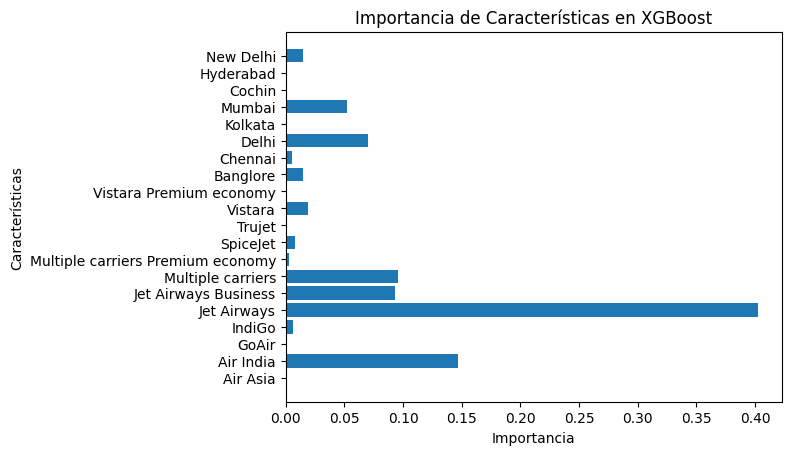

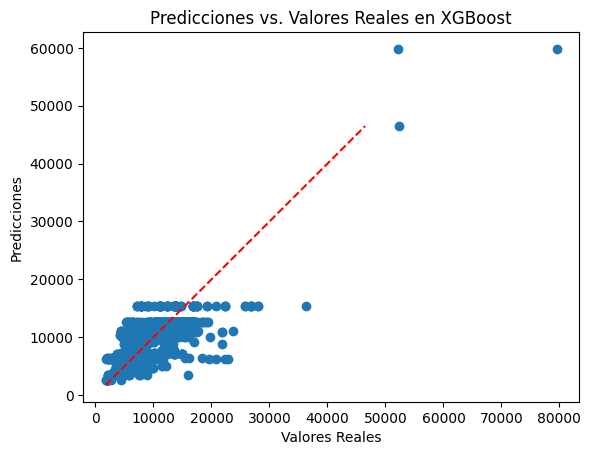

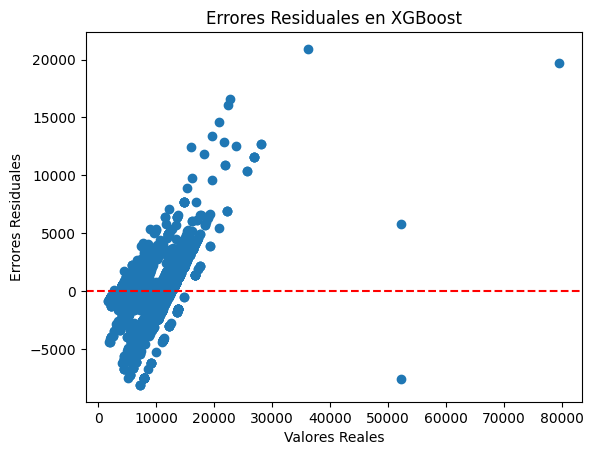

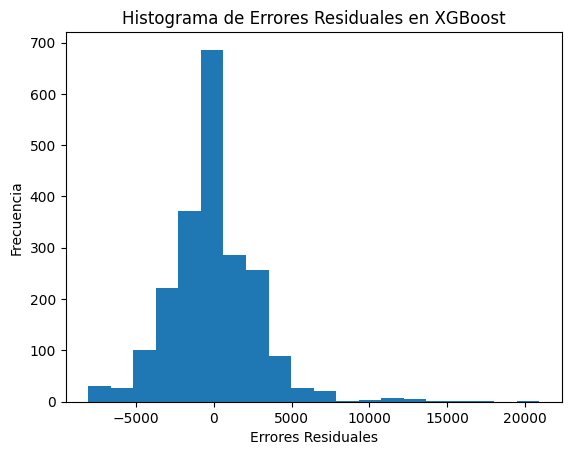

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn import metrics

y = num_var
X = oficial

# Normalizar los datos
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Recuperar nombres de características del DataFrame original
feature_names = list(X.columns)

# Iterar para ajustar el modelo y hacer predicciones varias veces
num_iteraciones = 100
resultados = []

max_r2_iteration = None
max_r2_value = float('-inf')

for i in range(num_iteraciones):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=i)

    # Crear y entrenar el modelo de XGBoost con regularización
    model = XGBRegressor(reg_alpha=0.1, reg_lambda=0.1, gamma=0.1)
    model.fit(X_train, y_train)

    # Hacer predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evaluar el rendimiento del modelo
    mae = metrics.mean_absolute_error(y_test, y_pred)
    mse = metrics.mean_squared_error(y_test, y_pred)
    rmse = metrics.mean_squared_error(y_test, y_pred, squared=False)
    r2 = metrics.r2_score(y_test, y_pred)

    # Almacenar los resultados en una lista
    resultados.append({
        'Iteración': i + 1,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R^2': r2,
        'Características Importantes': model.feature_importances_,
        'Valores Reales': y_test,
        'Predicciones': y_pred
    })

    # Actualizar el valor máximo de R^2 y la iteración correspondiente
    if r2 > max_r2_value:
        max_r2_value = r2
        max_r2_iteration = i + 1
        best_model = model  # Almacenar el modelo con el R^2 máximo

# Imprimir resultados de todas las iteraciones
resultados_df = pd.DataFrame(resultados)
print(resultados_df)

# Imprimir resultados de la iteración con el valor máximo de R^2
print("\nResultados de la iteración con el valor máximo de R^2:")
max_r2_row = resultados_df[resultados_df['Iteración'] == max_r2_iteration]
print(max_r2_row)

# Resumen de conclusiones
print("\nResumen de Conclusiones:")
print(f"Media MAE: {resultados_df['MAE'].mean()}")
print(f"Media MSE: {resultados_df['MSE'].mean()}")
print(f"Media RMSE: {resultados_df['RMSE'].mean()}")
print(f"Media R^2: {resultados_df['R^2'].mean()}")

# El valor más alto
print(f"\nValor MAE más alto: {resultados_df['MAE'].max()}")
print(f"Valor MSE más alto: {resultados_df['MSE'].max()}")
print(f"Valor RMSE más alto: {resultados_df['RMSE'].max()}")
print(f"Valor R^2 más alto: {max_r2_value}")

# Imprimir características importantes de la iteración con el valor máximo de R^2
print("\nCaracterísticas Importantes de la iteración con el valor máximo de R^2:")
feature_importances = max_r2_row['Características Importantes'].values[0]
for nombre, importancia in zip(feature_names, feature_importances):
    print(f"{nombre}: {importancia}")

# Visualizaciones adicionales
# Gráfico de Importancia de Características con Barras Horizontales
plt.barh(feature_names, feature_importances)
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de Características en XGBoost')
plt.show()

# Gráfico de Predicciones vs. Valores Reales
plt.scatter(max_r2_row['Valores Reales'].values[0], max_r2_row['Predicciones'].values[0])
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs. Valores Reales en XGBoost')
plt.show()

# Gráfico de Errores Residuales
residuals = max_r2_row['Valores Reales'].values[0] - max_r2_row['Predicciones'].values[0]
plt.scatter(max_r2_row['Valores Reales'].values[0], residuals)
plt.xlabel('Valores Reales')
plt.ylabel('Errores Residuales')
plt.title('Errores Residuales en XGBoost')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Histograma de Errores Residuales
plt.hist(residuals, bins=20)
plt.xlabel('Errores Residuales')
plt.ylabel('Frecuencia')
plt.title('Histograma de Errores Residuales en XGBoost')
plt.show()
